import dependencies

In [8]:
import pandas as pd
from collections import defaultdict
import sys

In [12]:
import pandas as pd

master_path = "../data/promiscuity/masterannot_allseq_withupdated_domainannot.csv"
out_path    = "../data/promiscuity/domains_per_entry.tsv"
cols = ["Entry", "domains", "domains_pfamscan", "length"]

master = pd.read_csv(master_path)

# Sanity check: these columns are protein-level, so they should not vary between
# the domain rows of the same protein. Fail loudly if an upstream edit breaks that.
n_var = master.groupby("Entry")[cols[1:]].nunique()
assert (n_var <= 1).all().all(), n_var[(n_var > 1).any(axis=1)]

out = (master[cols]
       .drop_duplicates(subset="Entry", keep="first")   # keeps original row order
       .reset_index(drop=True))

out.to_csv(out_path, sep="\t", index=False)
print(f"{len(master)} rows -> {len(out)} entries written to {out_path}")

41904 rows -> 39582 entries written to ../data/promiscuity/domains_per_entry.tsv


In [15]:
import pandas as pd
import numpy as np
from collections import defaultdict

# 1) Parameters
input_file = "../data/promiscuity/domains_per_entry.tsv"  # or your GH18‐filtered file
gh18_id     = "GH18"
output_file = "../data/promiscuity/partner_stats_converted_protein_domains_interproscan_GH18replacedfprint.tsv"

# 2) Load and filter
df = pd.read_csv(input_file, sep="\t",
                 
                 dtype=str)
df["domains"] = df["domains"].str.split()
gh = df[df["domains"].apply(lambda L: gh18_id in L)].copy()
N = len(gh)

# 3) Aggregate stats
n_GH18 = defaultdict(int)
neighbor_sets = defaultdict(set)

for domains in gh["domains"]:
    # unique partners per protein
    ups = {d for d in domains if d != gh18_id}
    for p in ups:
        n_GH18[p] += 1
    # record neighbors within each GH18 protein
    for i, dom in enumerate(domains):
        if dom == gh18_id:
            continue
        left  = domains[i-1] if i>0 else None
        right = domains[i+1] if i<len(domains)-1 else None
        for neigh in (left, right):
            if neigh and neigh != dom:
                neighbor_sets[dom].add(neigh)

# 4) Compute T and normalized sums
T_GH18 = {d: len(v) for d, v in neighbor_sets.items()}
sum_T = sum(T_GH18.values())

# 5) Build results
records = []
for dom in sorted(n_GH18):
    n_i = n_GH18[dom]
    T_i = T_GH18.get(dom, 0)
    pi_i = T_i / sum_T if sum_T>0 else 0.0
    f_i  = n_i / N
    phi_i = pi_i * np.log(pi_i / f_i) if pi_i>0 and f_i>0 else 0.0
    records.append({
        "Domain":   dom,
        "n_GH18":   n_i,
        "T_GH18":   T_i,
        "pi_GH18":  pi_i,
        "phi_GH18": phi_i
    })

partner_stats = pd.DataFrame(records, columns=["Domain","n_GH18","T_GH18","pi_GH18","phi_GH18"])

# 6) Save and preview
partner_stats.to_csv(output_file, sep="\t", index=False)
partner_stats.head()


,Domain,n_GH18,T_GH18,pi_GH18,phi_GH18
0,G3DSA:1.10.10.1270,1,1,0.000671,0.002199
1,G3DSA:1.10.10.60,1,1,0.000671,0.002199
2,G3DSA:1.10.101.10,5,1,0.000671,0.001120
3,G3DSA:1.10.1330.10,26,6,0.004024,0.007294
4,G3DSA:1.10.150.20,1,1,0.000671,0.002199


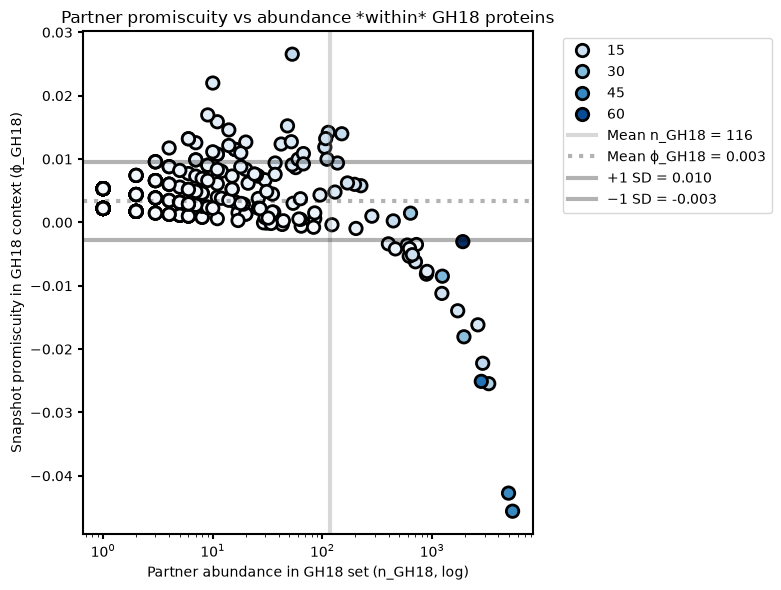

In [14]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/promiscuity/partner_stats_converted_protein_domains_interproscan_GH18replacedfprint.tsv", sep="\t")

# Compute stats for x and y
median_n = df["n_GH18"].median()
mean_n = df["n_GH18"].mean()

mean_phi = df["phi_GH18"].mean()
std_phi = df["phi_GH18"].std()

# Define thresholds for outliers (e.g., ±1 SD)
upper_thresh = mean_phi + std_phi
lower_thresh = mean_phi - std_phi

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="n_GH18",
    y="phi_GH18",
    hue="T_GH18",
    palette="Blues",
    s=80,
    edgecolor="black",
    linewidth=2
)

plt.xscale("log")

# Median and mean verticals
#plt.axvline(median_n, color="grey", alpha=0.3, linestyle="-", label=f"Median n_GH18 = {median_n:.0f}")
plt.axvline(mean_n, color="grey", alpha=0.3, linestyle="-", label=f"Mean n_GH18 = {mean_n:.0f}",linewidth=3)

# Add SD-based significance lines
plt.axhline(mean_phi, color="black", alpha=0.3, linestyle=":", label=f"Mean ϕ_GH18 = {mean_phi:.3f}", linewidth=3)
plt.axhline(upper_thresh, color="black", alpha=0.3, linestyle="-", label=f"+1 SD = {upper_thresh:.3f}", linewidth=3)
plt.axhline(lower_thresh, color="black", alpha=0.3, linestyle="-", label=f"−1 SD = {lower_thresh:.3f}", linewidth=3)

#increase thickness of axes lines
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
#also ticks
plt.gca().tick_params(width=1.5)


plt.xlabel("Partner abundance in GH18 set (n_GH18, log)")
plt.ylabel("Snapshot promiscuity in GH18 context (ϕ_GH18)")
plt.title("Partner promiscuity vs abundance *within* GH18 proteins")

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
#plt.savefig("251109partner_promiscuity_vs_abundance_GH18_SDcutoff_nomedian_bluesthickline2_70percentderep.png", dpi=600)
plt.show()


recompute promiscuity with 70% test

proteins: full 8,850 -> derep 1,601
domains scored in both sets: 83
Spearman rho(ϕ_full, ϕ_derep) = 0.953  (p = 7.8e-44)
overall classification agreement: 97.6%

  promiscuous:  10 domains in full set — 90% keep the call after dereplication
  housekeeper:   0 domains in full set — nan% keep the call after dereplication


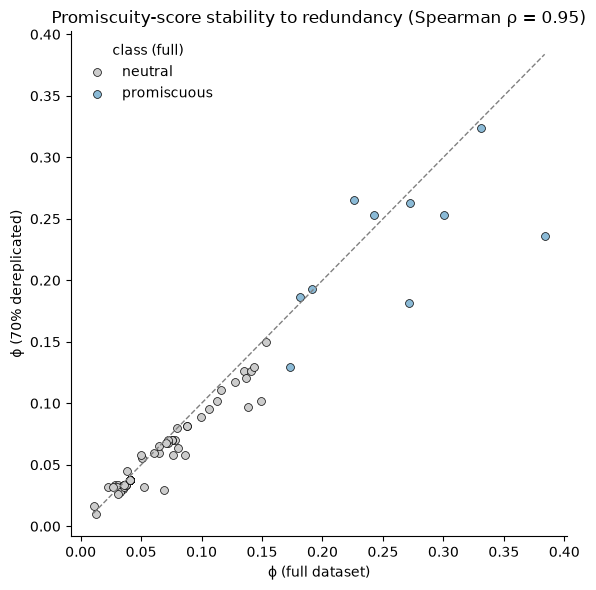

In [5]:
# ============================================================================
# Fig 2 promiscuity — robustness of the ϕ classification to sequence redundancy
# Recomputes n, T and ϕ (exactly as step3_phi_promiscuity.py) on the full set
# and on the 70% MMseqs-dereplicated representative set, then checks whether
# the promiscuous / housekeeper classification (±1 SD on ϕ) is stable.
#
# Addresses R2's Fig-2 concern: taxonomic oversampling inflates abundance n
# (T, a set cardinality, is redundancy-robust), which enters ϕ via f = n/N.
# ============================================================================
import pandas as pd, numpy as np
from collections import defaultdict
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

### EDIT ---------------------------------------------------------------------
FINGERPRINT = "../data/promiscuity/protein_non_GH18_fingerprints_labeled.tsv"  # ProteinID,Organism,Domains,Label
CLUSTER_TSV = "../data/annotation/mmseqs_derep/id70_cluster.tsv"              # rep <TAB> member  (70% id)
# ----------------------------------------------------------------------------

def compute_phi(df):
    """ϕ_d = (T_d/ΣT)·ln(T_d/f_d), f_d = n_d/N  — identical to step3_phi."""
    n = defaultdict(int); N = 0
    for doms in df["Domains"]:
        for d in doms: n[d] += 1; N += 1
    neigh = defaultdict(set)
    for doms in df["Domains"]:
        for i, d in enumerate(doms):
            if i > 0:               neigh[d].add(doms[i-1])
            if i < len(doms) - 1:   neigh[d].add(doms[i+1])
    sumT = sum(len(v) for v in neigh.values())
    rows = []
    for d, part in neigh.items():
        T = len(part); nd = n[d]; f = nd / N if N else 0
        if T > 0 and f > 0:
            rows.append((d, nd, T, (T / sumT) * np.log(T / f)))
    return pd.DataFrame(rows, columns=["Domain", "n", "T", "phi"]).set_index("Domain")

def classify(phi):
    m, sd = phi.mean(), phi.std()
    return pd.cut(phi, [-np.inf, m - sd, m + sd, np.inf],
                  labels=["housekeeper", "neutral", "promiscuous"])

# --- full dataset -----------------------------------------------------------
df = pd.read_csv(FINGERPRINT, sep="\t", names=["ProteinID", "Organism", "Domains", "Label"])
df["Domains"] = df["Domains"].fillna("").apply(str.split)
phi_full = compute_phi(df); phi_full["class_full"] = classify(phi_full["phi"])

# --- 70% dereplicated: keep one representative protein per cluster -----------
clu  = pd.read_csv(CLUSTER_TSV, sep="\t", names=["rep", "member"])
reps = set(pd.unique(clu["rep"]))
df_d = df[df["ProteinID"].isin(reps)].copy()
phi_d = compute_phi(df_d); phi_d["class_derep"] = classify(phi_d["phi"])

# --- compare ----------------------------------------------------------------
m = phi_full.join(phi_d[["phi", "class_derep"]], rsuffix="_d", how="inner")
rho, p = spearmanr(m["phi"], m["phi_d"])
agree = (m["class_full"].astype(str) == m["class_derep"].astype(str)).mean()
print(f"proteins: full {len(df):,} -> derep {len(df_d):,}")
print(f"domains scored in both sets: {len(m)}")
print(f"Spearman rho(ϕ_full, ϕ_derep) = {rho:.3f}  (p = {p:.1e})")
print(f"overall classification agreement: {agree*100:.1f}%\n")
for cls in ["promiscuous", "housekeeper"]:
    sub = m[m["class_full"] == cls]
    kept = (sub["class_derep"].astype(str) == cls).mean() if len(sub) else np.nan
    print(f"  {cls:>11}: {len(sub):>3} domains in full set — {kept*100:.0f}% keep the call after dereplication")

# --- figure -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
cols = {"promiscuous": "#8bbad6", "housekeeper": "#D8A47D", "neutral": "#cccccc"}
for cls, g in m.groupby("class_full", observed=True):
    ax.scatter(g["phi"], g["phi_d"], s=32, edgecolor="black", linewidth=0.5,
               color=cols.get(str(cls)), label=str(cls))
lim = [m[["phi", "phi_d"]].min().min(), m[["phi", "phi_d"]].max().max()]
ax.plot(lim, lim, "--", color="grey", lw=1)
ax.set_xlabel("ϕ (full dataset)"); ax.set_ylabel("ϕ (70% dereplicated)")
ax.set_title(f"Promiscuity-score stability to redundancy (Spearman ρ = {rho:.2f})")
ax.legend(frameon=False, title="class (full)")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout()#; plt.savefig("fig2_phi_dereplication_stability.png", dpi=1200); plt.show()